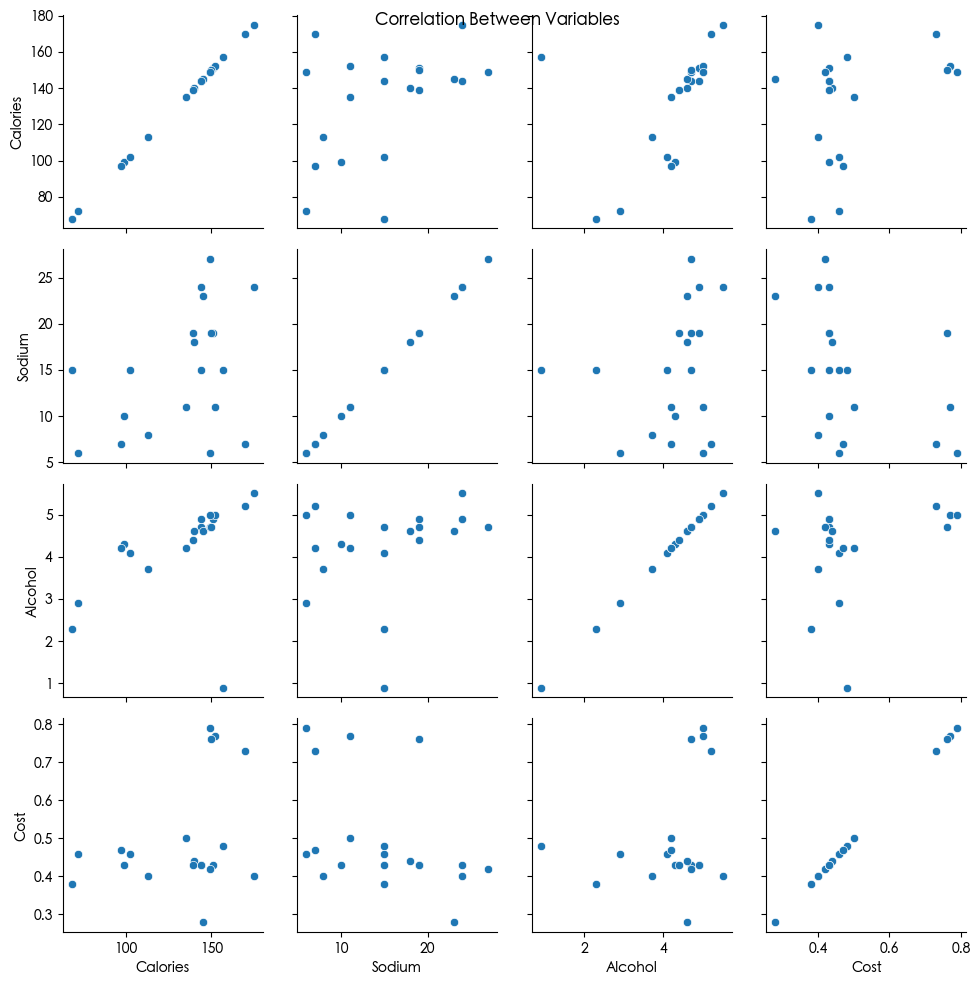

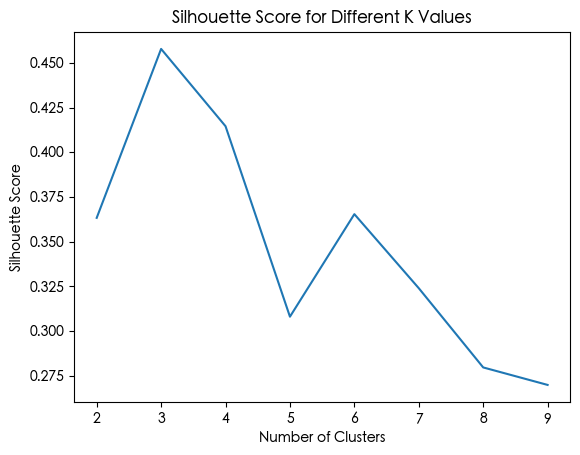

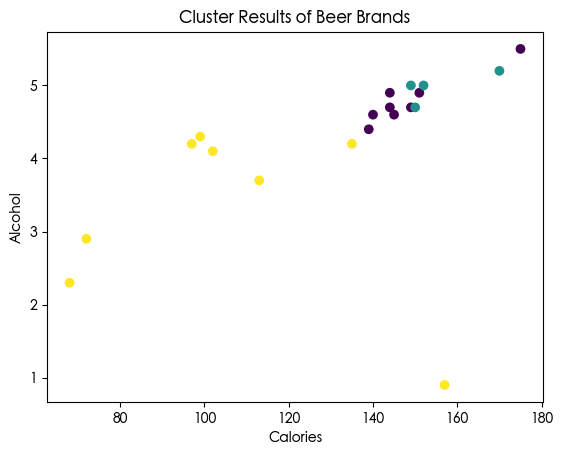

Cluster Centers:
         Calories  Sodium  Alcohol    Cost
cluster                                   
0         148.375  21.125   4.7875  0.4075
1         155.250  10.750   4.9750  0.7625
2         105.375  10.875   3.3250  0.4475

Beer Brands and Their Clusters:
                    Name  cluster
0              Budweiser        0
1                Schlitz        0
2              Lowenbrau        2
3            Kronenbourg        1
4               Heineken        1
5          Old_Milwaukee        0
6             Augsberger        0
7   Srohs_Bohemian_Style        0
8            Miller_Lite        2
9        Budweiser_Light        2
10                 Coors        0
11           Coors_Light        2
12        Michelob_Light        2
13                 Becks        1
14                 Kirin        1
15     Pabst_Extra_Light        2
16                 Hamms        0
17   Heilemans_Old_Style        0
18   Olympia_Goled_Light        2
19         Schlitz_Light        2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from matplotlib import rcParams

# 配置 matplotlib 使用字体
rcParams['font.sans-serif'] = ['Heiti TC']
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 读取啤酒数据集
beer = pd.read_csv('beer.csv')
# 选择用于聚类的特征
X = beer[['Calories', 'Sodium', 'Alcohol', 'Cost']]

# 可视化数据的相关性，使用 PairGrid
g = sns.PairGrid(beer[['Calories', 'Sodium', 'Alcohol', 'Cost']])
g.map(sns.scatterplot)
plt.suptitle('Correlation Between Variables')
plt.show()

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 计算不同 K 值对应的轮廓系数
scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    scores.append(score)

# 绘制轮廓系数随 K 值变化的曲线
plt.plot(range(2, 10), scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.show()

# 假设选择 K=3 作为最优簇数
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_scaled)
beer['cluster'] = kmeans.labels_

# 可视化聚类结果（以热量和酒精含量为例）
plt.scatter(beer['Calories'], beer['Alcohol'], c=beer['cluster'], cmap='viridis')
plt.xlabel('Calories')
plt.ylabel('Alcohol')
plt.title('Cluster Results of Beer Brands')
plt.show()

# 计算每个簇的质心（仅对数值型列进行计算）
centers = beer[['Calories', 'Sodium', 'Alcohol', 'Cost']].groupby(beer['cluster']).mean()
print("Cluster Centers:")
print(centers)

# 输出每个啤酒品牌所属的簇
print("\nBeer Brands and Their Clusters:")
print(beer[['Name', 'cluster']])